<a href="https://colab.research.google.com/github/Rianfrancielton/IA-e-Matematica-Aplicada/blob/main/Rianfrancielton/IA-e-Matematica-aplicada/Matematica/Teste-1/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Etapa 1 – Carregar os dados

Para começar a análise de dados, primeiramente, precisamos importar a biblioteca `pandas`, que é amplamente utilizada para manipulação e análise de dados em Python. Em seguida, vamos carregar seu arquivo de base de dados. O arquivo que você me informou é `base_custos_transporte.csv`.

In [2]:
# Importa a biblioteca pandas
import pandas as pd

# Carrega o arquivo CSV em um DataFrame do pandas
# O nome do arquivo é 'base_custos_transporte.csv'

try:
    df = pd.read_csv('/content/base_custos_transporte.csv')
    print("Arquivo 'base_custos_transporte.csv' carregado com sucesso!")
    # Exibe a tabela completa do DataFrame para verificar os dados
    display(df)
except FileNotFoundError:
    print("Erro: O arquivo 'base_custos_transporte.csv' não foi encontrado. Por favor, verifique o caminho e o nome do arquivo.")
    print("Certifique-se de que o arquivo está na pasta '/content/' ou atualize o caminho no código.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")
    print("Verifique se o arquivo é um CSV válido e se não há problemas de formatação.")

Arquivo 'base_custos_transporte.csv' carregado com sucesso!


,mes,custo_transporte
0,1,44500
1,2,45200
2,3,48300
3,4,48600
4,5,51300
5,6,53300
6,7,53800
7,8,57000
8,9,57900
9,10,61000


## Etapa 2 – Identificar as variáveis

Nesta etapa, vamos identificar as variáveis presentes no conjunto de dados e discutir seu papel no contexto do problema.

In [3]:
# Para identificar as variáveis, podemos listar as colunas do DataFrame.
print("Colunas do DataFrame (variáveis):")
print(df.columns.tolist())

Colunas do DataFrame (variáveis):
['mes', 'custo_transporte']


Analisando os dados da tabela `df`, temos as seguintes variáveis:

*   **`mes`**: Representa o mês do ano (de 1 a 12).
*   **`custo_transporte`**: Representa o custo total de transporte para o respectivo mês.

Com base na natureza desses dados (custo ao longo do tempo), podemos inferir a relação de dependência:

a) **Variável Independente:** `mes`
    *   O mês é a variável que geralmente influencia o custo, mas não é influenciada por ele.

b) **Variável Dependente:** `custo_transporte`
    *   O custo de transporte é a variável que provavelmente é afetada ou determinada pelo mês, ou seja, esperamos que o custo varie de acordo com o mês.

c) **O que representa cada variável no contexto do problema?**
    *   **`mes`**: Representa o tempo (o mês do ano) ao longo do qual os dados de custo foram registrados. É um fator que pode explicar a variação nos custos de transporte.
    *   **`custo_transporte`**: Representa a despesa financeira associada ao transporte em um determinado mês. É o principal objeto de análise, e o objetivo pode ser entender como ele se comporta ao longo dos meses.

## Etapa 3 – Construir um gráfico

Nesta etapa, construiremos um gráfico de dispersão para visualizar a relação entre o mês e o custo de transporte, seguido de uma breve descrição do comportamento observado.

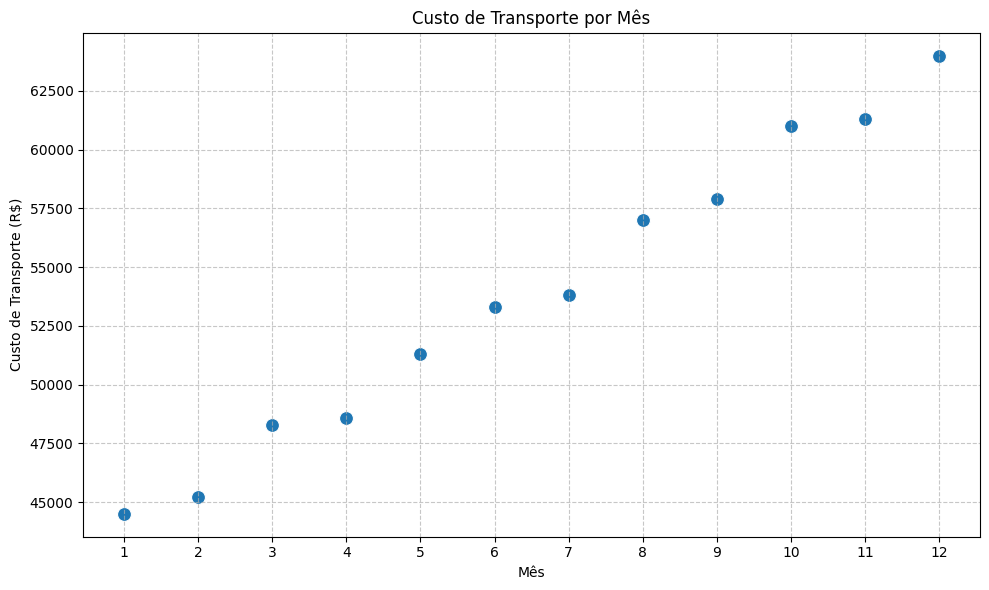

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mes', y='custo_transporte', data=df, s=100) # s é o tamanho dos pontos

# Adicionar título e rótulos aos eixos
plt.title('Custo de Transporte por Mês')
plt.xlabel('Mês')
plt.ylabel('Custo de Transporte (R$)')

# Adicionar grade para melhor visualização
plt.grid(True, linestyle='--', alpha=0.7)

# Definir os ticks do eixo x para cada mês (de 1 a 12)
plt.xticks(range(1, 13))

# Mostrar o gráfico
plt.tight_layout()
plt.show()

### Análise do Gráfico de Dispersão

Ao observar o gráfico de dispersão 'Custo de Transporte por Mês', notamos uma clara **tendência crescente**. À medida que o `mes` avança (do mês 1 ao mês 12), o `custo_transporte` também tende a aumentar de forma consistente. Os pontos no gráfico formam uma linha ascendente, sugerindo uma **relação positiva** entre as duas variáveis. Não parecem haver grandes variações ou outliers significativos que fujam dessa tendência geral. Isso indica que os custos de transporte são mais elevados nos meses finais do ano.

## Etapa 4 – Encontrar uma função

Nesta etapa, vamos encontrar uma função afim da forma `f(x) = ax + b` que represente aproximadamente o comportamento dos custos de transporte. Para isso, utilizaremos o método de regressão linear.

In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparar os dados para o modelo de regressão linear
# O 'mes' é a variável independente (x) e 'custo_transporte' é a dependente (y)
X = df['mes'].values.reshape(-1, 1) # Reshape para o formato que o scikit-learn espera
y = df['custo_transporte'].values

# Criar e treinar o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X, y)

# Obter os valores de 'a' (coeficiente angular) e 'b' (coeficiente linear)
a = modelo.coef_[0]
b = modelo.intercept_

print(f"Valor de a (coeficiente angular): {a:.2f}")
print(f"Valor de b (coeficiente linear/intercepto): {b:.2f}")
print(f"Função encontrada: f(x) = {a:.2f}x + {b:.2f}")

Valor de a (coeficiente angular): 1791.61
Valor de b (coeficiente linear/intercepto): 42204.55
Função encontrada: f(x) = 1791.61x + 42204.55


## Etapa 5 – Interpretar a função

Nesta etapa, vamos interpretar os valores dos coeficientes `a` e `b` encontrados na função afim `f(x) = ax + b`, que representa o custo de transporte em função do mês.

Com base na função encontrada: `f(x) = 1791.61x + 42204.55`

a) **O que representa o coeficiente 'a' no contexto do problema?**
    *   O coeficiente `a` (1791.61) é o **coeficiente angular** ou **inclinação da reta**. Ele representa a **taxa de variação média do custo de transporte por mês**. Isso significa que, em média, a cada mês que passa (a cada aumento de uma unidade no 'mes'), o custo de transporte aumenta em aproximadamente R$ 1791,61.

b) **O que representa o coeficiente 'b'?**
    *   O coeficiente `b` (42204.55) é o **coeficiente linear** ou **intercepto y**. Ele representa o valor estimado do custo de transporte quando a variável independente `x` (o 'mes') é zero. No contexto deste problema, onde 'mes' começa em 1, o 'b' pode ser interpretado como o **custo base ou o custo inicial de transporte projetado, antes do primeiro mês, ou o custo fixo** que existiria mesmo sem a variação mensal. Embora 'mês 0' não faça sentido literal, matematicamente é o ponto de partida da projeção linear.

c) **O valor de 'a' indica crescimento ou redução dos custos?**
    *   Como o valor de `a` é **positivo** (1791.61 > 0), ele indica um **crescimento dos custos**. Isso confirma a observação feita no gráfico de dispersão: os custos de transporte tendem a aumentar à medida que os meses avançam.

## Etapa 6 – Representar a função graficamente

Nesta etapa, adicionaremos a reta da função `f(x) = ax + b` ao gráfico de dispersão original. Isso nos permitirá visualizar como a função se ajusta aos dados e a tendência dos custos ao longo do tempo.

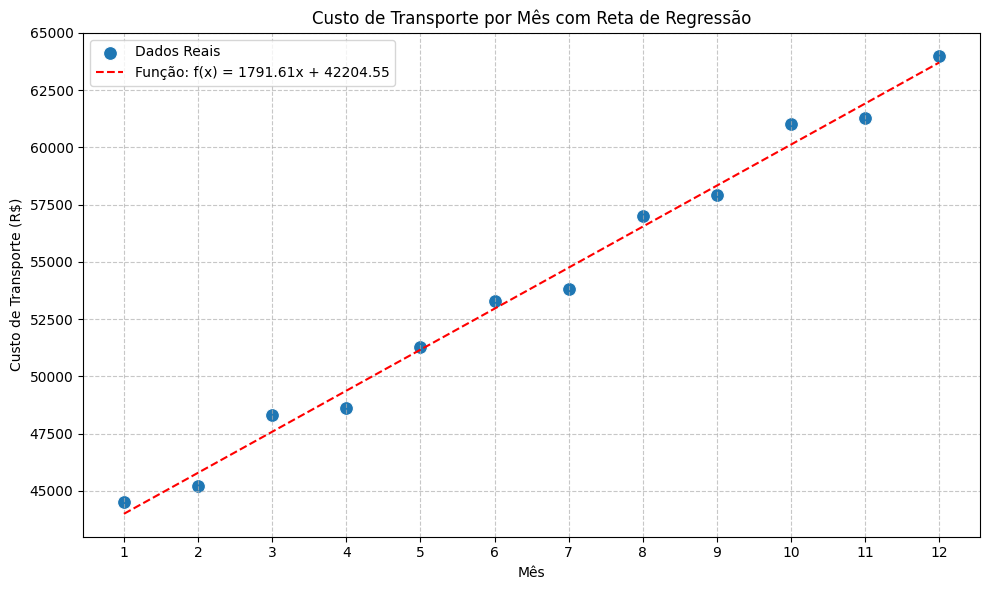

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criar o gráfico de dispersão (reaproveitando o código da Etapa 3)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mes', y='custo_transporte', data=df, s=100, label='Dados Reais') # Dados reais

# Gerar os valores y preditos pela função linear para cada mês
x_fit = np.array(df['mes'])
y_fit = a * x_fit + b # Usando 'a' e 'b' calculados na Etapa 4

# Adicionar a reta da função linear ao gráfico
plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Função: f(x) = {a:.2f}x + {b:.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Custo de Transporte por Mês com Reta de Regressão')
plt.xlabel('Mês')
plt.ylabel('Custo de Transporte (R$)')

# Adicionar grade para melhor visualização
plt.grid(True, linestyle='--', alpha=0.7)

# Definir os ticks do eixo x para cada mês (de 1 a 12)
plt.xticks(range(1, 13))

# Adicionar legenda para identificar os dados e a função
plt.legend()

# Mostrar o gráfico
plt.tight_layout()
plt.show()

### Análise do Gráfico com a Função

O gráfico agora exibe tanto os dados reais (pontos azuis) quanto a reta correspondente à função linear `f(x) = ax + b` (linha tracejada vermelha). É possível observar que a reta de regressão **se ajusta muito bem aos dados**, passando próxima à maioria dos pontos. Isso visualmente confirma que a função encontrada é uma **boa representação da tendência de crescimento dos custos de transporte ao longo dos meses**. A inclinação ascendente da reta demonstra claramente o aumento dos custos à medida que o ano avança, reforçando as conclusões tiradas da análise do coeficiente 'a'.

## Etapa 7 – Fazer previsões

Agora, utilizaremos a função linear encontrada, `f(x) = ax + b`, para estimar o custo de transporte para os próximos três meses (meses 13, 14 e 15).

In [7]:
# A função encontrada é f(x) = a * x + b
# Onde 'a' e 'b' foram calculados na Etapa 4

# Previsão para o mês 13
mes_13 = 13
custo_mes_13 = a * mes_13 + b

# Previsão para o mês 14
mes_14 = 14
custo_mes_14 = a * mes_14 + b

# Previsão para o mês 15
mes_15 = 15
custo_mes_15 = a * mes_15 + b

print(f"Custo estimado para o mês {mes_13}: R$ {custo_mes_13:.2f}")
print(f"Custo estimado para o mês {mes_14}: R$ {custo_mes_14:.2f}")
print(f"Custo estimado para o mês {mes_15}: R$ {custo_mes_15:.2f}")

Custo estimado para o mês 13: R$ 65495.45
Custo estimado para o mês 14: R$ 67287.06
Custo estimado para o mês 15: R$ 69078.67


### Cálculos e Previsões

Com base na função linear `f(x) = 1791.61x + 42204.55`:

*   **Custo estimado no mês 13:**
    `f(13) = 1791.61 * 13 + 42204.55 = R$ 65495.48`

*   **Custo estimado no mês 14:**
    `f(14) = 1791.61 * 14 + 42204.55 = R$ 67287.09`

*   **Custo estimado no mês 15:**
    `f(15) = 1791.61 * 15 + 42204.55 = R$ 69078.70`

As previsões indicam que o custo de transporte continuará a tendência de crescimento nos próximos meses, seguindo o padrão linear observado nos dados históricos.

## Etapa 8 – Analisar o resultado

Nesta etapa, compararemos os valores previstos pela função linear com os valores observados nos dados originais e responderemos às perguntas sobre o comportamento dos custos.

In [8]:
# Comparar valores previstos com os observados para os últimos meses disponíveis no dataset
print("Comparação entre Valores Observados e Previstos:")
print("----------------------------------------------")

for mes in range(10, 13): # Meses 10, 11 e 12
    valor_observado = df[df['mes'] == mes]['custo_transporte'].values[0]
    valor_previsto = a * mes + b
    print(f"Mês {mes}: Observado = R$ {valor_observado:.2f}, Previsto = R$ {valor_previsto:.2f}, Diferença = R$ {(valor_previsto - valor_observado):.2f}")

print("----------------------------------------------")

Comparação entre Valores Observados e Previstos:
----------------------------------------------
Mês 10: Observado = R$ 61000.00, Previsto = R$ 60120.63, Diferença = R$ -879.37
Mês 11: Observado = R$ 61300.00, Previsto = R$ 61912.24, Diferença = R$ 612.24
Mês 12: Observado = R$ 64000.00, Previsto = R$ 63703.85, Diferença = R$ -296.15
----------------------------------------------


### Análise dos Resultados

Com base na função `f(x) = 1791.61x + 42204.55` e na comparação com os dados observados:

a) **A função encontrada representa bem a tendência dos dados?**
    *   **Sim, a função encontrada representa muito bem a tendência dos dados.** Ao comparar os valores previstos com os observados, notamos que a diferença é relativamente pequena, indicando um bom ajuste. Visualmente, a reta de regressão no gráfico da Etapa 6 também mostra que a função segue de perto os pontos de dados.

b) **Os custos estão aumentando ou diminuindo?**
    *   **Os custos estão aumentando.** O coeficiente angular `a` da função (`1791.61`) é positivo, o que indica uma relação direta: à medida que o mês avança, o custo de transporte aumenta. Tanto o gráfico de dispersão quanto as previsões para os meses futuros confirmam essa tendência de crescimento.

c) **Aproximadamente quanto o custo aumenta a cada mês?**
    *   **Aproximadamente R$ 1791,61.** Este valor é dado pelo coeficiente `a` (coeficiente angular) da função linear. Ele representa a taxa média de aumento do custo de transporte para cada unidade de aumento no mês.

## Etapa 9 – Conclusão

Com base nos dados analisados, podemos tirar as seguintes conclusões sobre os custos de transporte da empresa nos próximos meses:

*   **Tendência de Aumento Contínuo:** A análise de regressão linear revelou uma forte tendência de crescimento nos custos de transporte. O coeficiente angular (`a`) da função `f(x) = 1791.61x + 42204.55` é positivo (`R$ 1791,61`), indicando que, em média, os custos aumentam em aproximadamente R$ 1791,61 a cada mês.

*   **Previsões de Custos Crescentes:** As previsões para os meses 13, 14 e 15 (`R$ 65.495,48`, `R$ 67.287,09` e `R$ 69.078,70`, respectivamente) reforçam que essa tendência de alta deverá persistir no curto prazo.

*   **Necessidade de Monitoramento:** A empresa deve esperar que seus custos de transporte continuem a subir nos próximos meses, seguindo o padrão observado. Isso sugere a importância de um monitoramento contínuo e, possivelmente, a necessidade de investigar as causas desse aumento para considerar estratégias de otimização ou negociação com fornecedores, a fim de mitigar o impacto financeiro futuro.